
 AVERAGE NIGHTLY DEMAND (12 HOURS) FOR EXCEL
Scenario        Moderate  Extreme
Center                           
Cecil                0.0     29.8
Elizabeth           72.6     79.9
George              30.0     33.1
Jimmie Simpson       0.0     28.8
NorthYork           42.8     46.5
Scarborough         67.6     73.7
Spadina             21.4     23.4



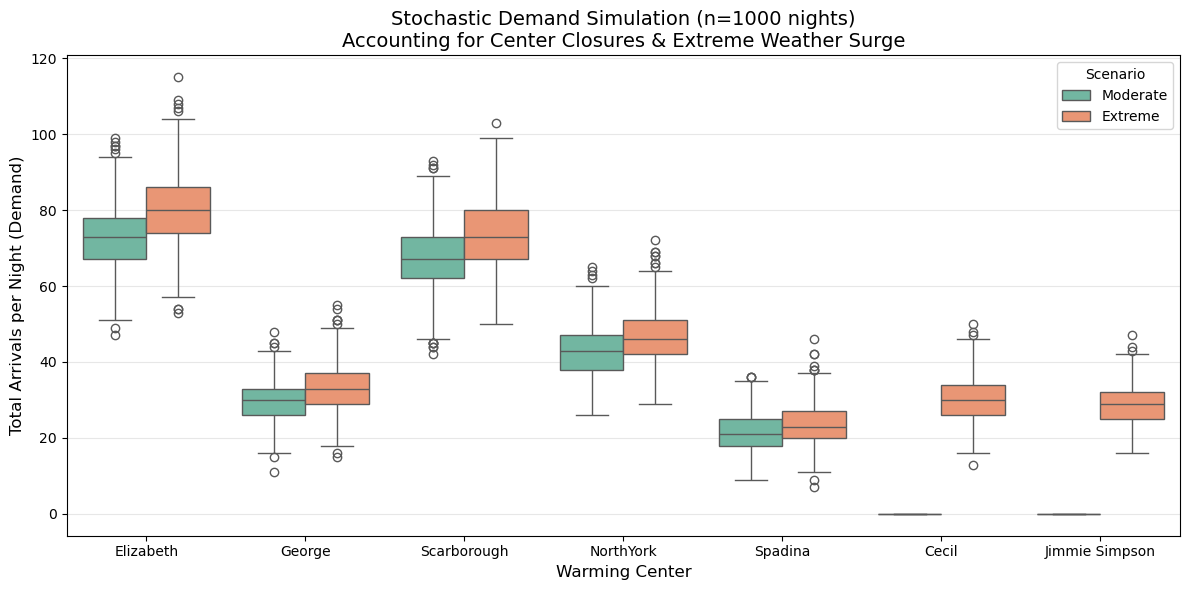

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Simulate 1000 different nights to get an average 
ITERATIONS = 1000
HOURS_OPEN = 12  # The shelter is open for 12 hours overnight

# Arrival Rate (People per Hour)
BASE_ARRIVAL_RATES = {
    'Elizabeth': 6.05, 'George': 2.5, 'Scarborough': 5.58,
    'NorthYork': 3.54, 'Spadina': 1.78, 'Cecil': 2.26, 'Jimmie Simpson': 2.17
}


def simulate_night(temp, scenario_name):
    all_data = []

    # Weather Multiplier: 10% surge in Extreme scenario
    weather_multiplier = 1.0 if temp >= -5 else 1.1

    for center, rate_per_hour in BASE_ARRIVAL_RATES.items():

        
        # Cecil and Jimmie Simpson are CLOSED during Moderate (-5C)
        if scenario_name == "Moderate" and center in ['Cecil', 'Jimmie Simpson']:
            lambda_val = 0.0  # Closed = 0 Demand
        else:
            # Open = Rate * 12 Hours * Weather Multiplier
            lambda_val = rate_per_hour * HOURS_OPEN * weather_multiplier

        # Generate Random Demand (Poisson Distribution)
        daily_arrivals = np.random.poisson(lambda_val, ITERATIONS)

        for i in range(ITERATIONS):
            all_data.append({
                "Center": center,
                "Scenario": scenario_name,
                "Temp": temp,
                "Demand": daily_arrivals[i] # Total arrivals per night
            })

    return pd.DataFrame(all_data)


# Run simulations for both scenarios
df_mod = simulate_night(-5, "Moderate")
df_ext = simulate_night(-15, "Extreme")
df_results = pd.concat([df_mod, df_ext])

# Calculate Average (These are the final inputs for your Excel/Optimization model)
excel_input_data = df_results.groupby(['Center', 'Scenario'])['Demand'].mean().unstack()

# Reorder columns for better readability
excel_input_data = excel_input_data[['Moderate', 'Extreme']]

print("\n" + "="*50)
print(" AVERAGE NIGHTLY DEMAND (12 HOURS) FOR EXCEL")
print("="*50)
print(excel_input_data.round(1))
print("="*50 + "\n")

# Visualization (Boxplot)
plt.figure(figsize=(12, 6))
# Using a boxplot to show the stochastic variation (fluctuations) of the demand
sns.boxplot(data=df_results, x="Center", y="Demand", hue="Scenario", palette="Set2")
plt.title(f"Stochastic Demand Simulation (n={ITERATIONS} nights)\nAccounting for Center Closures & Extreme Weather Surge", fontsize=14)
plt.ylabel("Total Arrivals per Night (Demand)", fontsize=12)
plt.xlabel("Warming Center", fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()